In [1]:
import numpy as np
import pandas as pd
from transformers import AutoImageProcessor, AutoModel
import torch
import os
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print('device:',device)

device: cuda


In [3]:
if Path('/kaggle/input').exists():
    model_path = '/kaggle/input/models/metaresearch/dinov2/pytorch/base/1/'
    dataset_path = '/kaggle/input/datasets/xiaose/cityscapes/Cityspaces/images'
else:
    notebook_path = Path.cwd()
    root_path = notebook_path.parent.parent 
    dataset_path = root_path / 'data' / 'Cityspaces' / 'images'
    model_path = root_path / 'model'
print(f'Model path: {model_path}\nDataset path: {dataset_path}')

Model path: /home/hxastur/vscode-projects/autonomous-driving/model
Dataset path: /home/hxastur/vscode-projects/autonomous-driving/data/Cityspaces/images


In [4]:
# Loading
embeddings_data_path = root_path / 'data' / "cityscapes_dino_embeddings.npz"
data = np.load(
    embeddings_data_path,
    allow_pickle=True
)

embeddings = data["embeddings"]
paths = data["paths"]

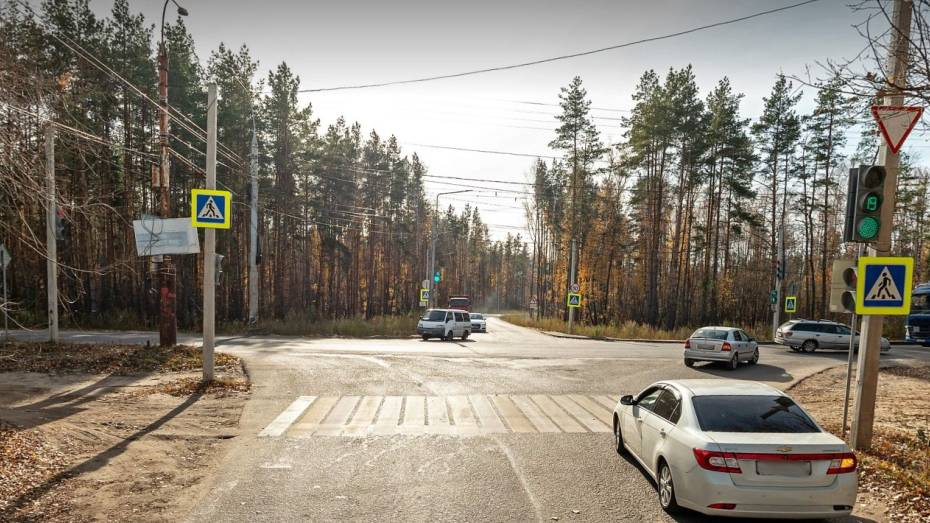

In [13]:
demo_img_path = root_path / 'data' / 'demo-retrieval' / '8789b5073dbb0ebbf4624361cdb35227.jpg'
from PIL import Image
demo_img = Image.open(demo_img_path)
demo_img

In [10]:
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

In [36]:
inputs_demo = processor(images=demo_img, return_tensors="pt")
outputs_demo = model(**inputs_demo)
last_hidden_states = outputs_demo.last_hidden_state[:, 0]
detached = last_hidden_states.detach().numpy()
sim = cosine_similarity(detached,embeddings)
nearest = np.argsort(-sim)[0]
five_nearest = nearest[:5]

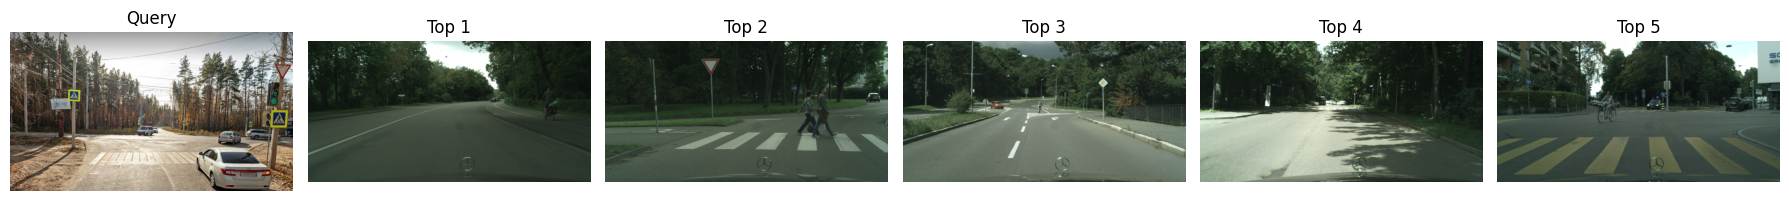

In [37]:
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(demo_img)
axes[0].set_title("Query")
axes[0].axis("off")

for i, idx in enumerate(five_nearest):
    img = Image.open(paths[idx])
    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"Top {i+1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()